<a href="https://colab.research.google.com/github/PiyushGit11/Generative-AI-internship/blob/main/Day6/CNNBrainTumour1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"
IMG_SIZE = 128 # Define a consistent image size for the CNN

# Class names for the brain tumor dataset ('Normal' for label 0, 'Brain Tumor' for label 1)
class_names = ['Normal', 'Brain Tumor']

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

images = []
labels = []

# Path to the directories containing images for 'Normal' and 'Brain Tumor'
# Based on the 'ls' output showing 'extracted_images/yes' and 'extracted_images/no'
normal_images_dir = os.path.join(extract_path, 'no')
tumor_images_dir = os.path.join(extract_path, 'yes')

# Function to load images from a directory and assign a specific label
def load_images_from_folder(folder_path, label):
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        # Ensure it's an image file (e.g., .jpg, .png)
        if not os.path.isfile(img_path) or not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img = cv2.imread(img_path)

        if img is not None:
            # Convert to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Resize image to a consistent size
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label)
        else:
            print(f"Warning: Could not load image {img_path}")

# Load 'Normal' images (label 0) from the 'no' folder
print(f"Loading images from: {normal_images_dir}")
load_images_from_folder(normal_images_dir, 0) # 0 corresponds to 'Normal'

# Load 'Brain Tumor' images (label 1) from the 'yes' folder
print(f"Loading images from: {tumor_images_dir}")
load_images_from_folder(tumor_images_dir, 1) # 1 corresponds to 'Brain Tumor'

print(f"Found {len(images)} images with {len(set(labels))} unique labels.")
print(f"Class names and their mapping: {dict(zip(class_names, range(len(class_names))))}")

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Normalize images (pixel values to 0-1)
images = images / 255.0

# Reshape for CNN input (add channel dimension for grayscale images: (num_samples, IMG_SIZE, IMG_SIZE, 1))
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Perform train-test split
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

Loading images from: extracted_images/no
Loading images from: extracted_images/yes
Found 253 images with 2 unique labels.
Class names and their mapping: {'Normal': 0, 'Brain Tumor': 1}
x_train shape: (202, 128, 128, 1)
y_train shape: (202,)
x_test shape: (51, 128, 128, 1)
y_test shape: (51,)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 544ms/step - accuracy: 0.6485 - loss: 1.4575 - val_accuracy: 0.6078 - val_loss: 0.6245
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 436ms/step - accuracy: 0.7030 - loss: 0.6311 - val_accuracy: 0.7647 - val_loss: 0.6136
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 541ms/step - accuracy: 0.7475 - loss: 0.5636 - val_accuracy: 0.8235 - val_loss: 0.5442
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 449ms/step - accuracy: 0.7822 - loss: 0.5011 - val_accuracy: 0.7647 - val_loss: 0.5022
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 450ms/step - accuracy: 0.8168 - loss: 0.4584 - val_accuracy: 0.8431 - val_loss: 0.5195
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 456ms/step - accuracy: 0.8218 - loss: 0.4289 - val_accuracy: 0.8627 - val_loss: 0.4593
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/step - accuracy: 0.8614 - loss: 0.3600 - val_accuracy: 0.8627 - val_loss: 0.4246
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 483ms/step - accuracy: 0.8663 - loss: 0.3215 - val_accuracy: 0.8235 - val_loss: 0.4282
Epo

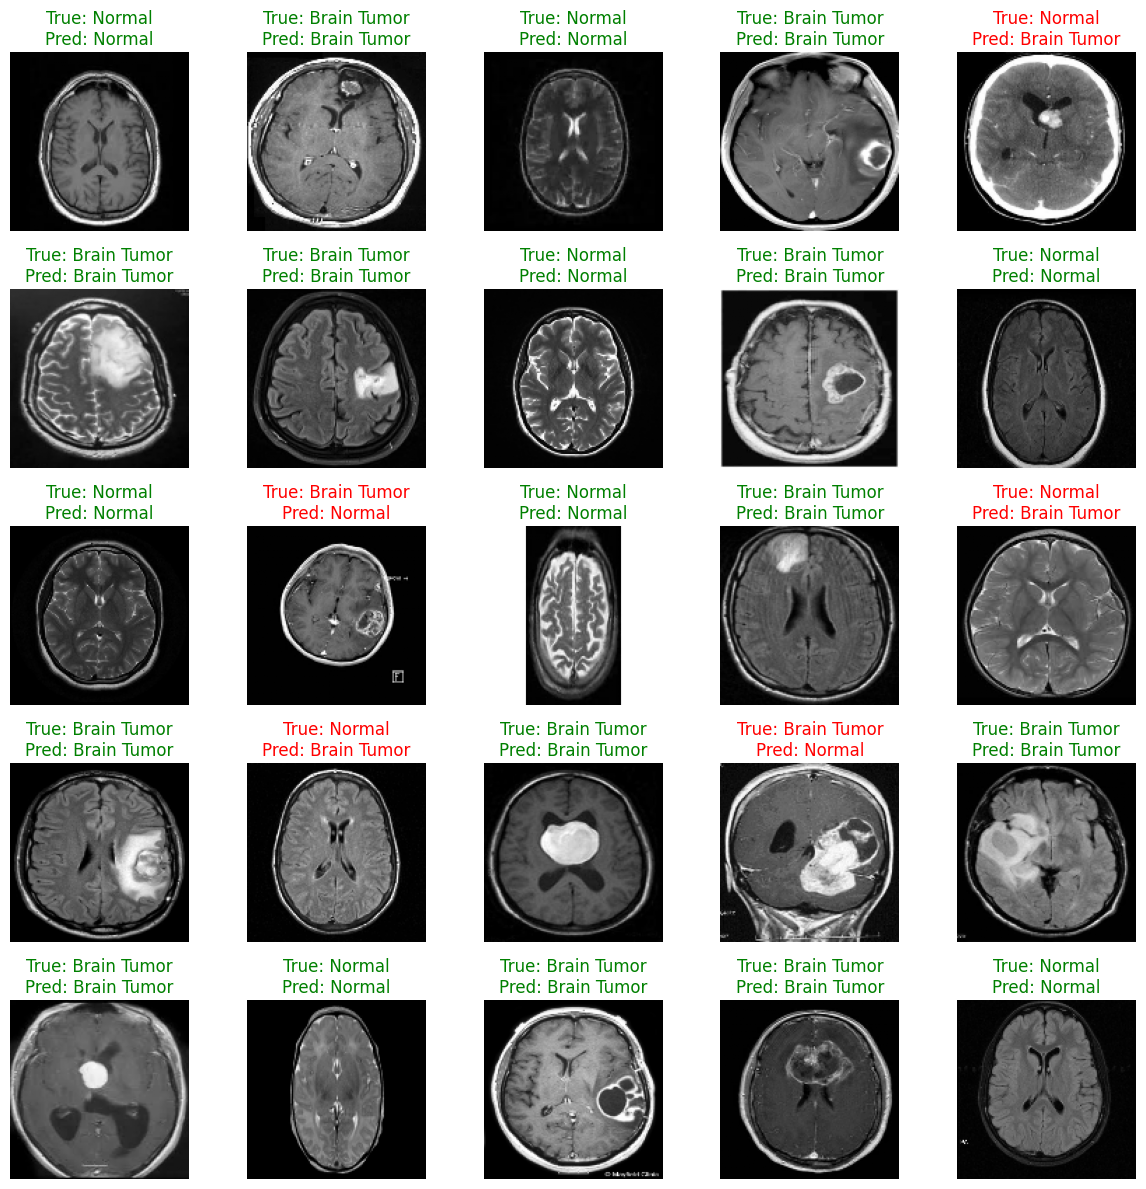

In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# The variables x_train, y_train, x_test, y_test, IMG_SIZE, and class_names
# are expected to be defined in the previous data loading and preprocessing cell.

# Build a CNN model suitable for brain tumor detection with Dropout for regularization
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)), # Input shape adjusted for grayscale brain images
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25), # Added dropout layer

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25), # Added dropout layer

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5), # Added dropout layer before output to prevent overfitting on dense layer
    keras.layers.Dense(len(class_names), activation='softmax') # Output units equal to the number of classes (Normal, Brain Tumor)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with the preprocessed brain tumor data
# Using validation_data to monitor performance on unseen data during training
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test)) # Increased epochs to 10 for better training with dropout

# Evaluate model performance on the test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Predict on test images
predictions = model.predict(x_test)

# Plot some predictions to visualize model performance
plt.figure(figsize=(12, 12)) # Adjusted figure size for better visualization

# Plot up to 25 images (5x5 grid)
num_images_to_plot = min(25, len(x_test))
for i in range(num_images_to_plot):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")

    # Get true and predicted labels
    true_label = class_names[y_test[i]]
    predicted_label_idx = np.argmax(predictions[i])
    predicted_label = class_names[predicted_label_idx]

    # Set title with true and predicted labels
    plt.title(f"True: {true_label}\nPred: {predicted_label}",
              color="green" if true_label == predicted_label else "red")
    plt.axis("off")
plt.tight_layout()
plt.show()